In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 11.0 MB/s eta 0:00:00


In [3]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pmdarima.arima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from tqdm import tqdm

In [4]:
# TOP_STOCKS = ["NVDA", "AAPL", "MSFT", "AMZN", "GOOGL", "GOOG", "META", "AVGO", "TSLA", "ASML"]
STOCKS = ['AAPL', 'TSLA', 'MSFT']
OUTPUT_PATH = Path("/content/drive/MyDrive/Data Science projects/stock_market_prediction/outputs")

df_adjclose = pd.read_csv(OUTPUT_PATH /'adjclose_final_data.csv')

train_data = joblib.load(OUTPUT_PATH /'train_data.joblib')
test_data = joblib.load(OUTPUT_PATH /'test_data.joblib')

In [5]:
# Augmented Dickey–Fuller test
for stock in STOCKS:
    df = df_adjclose[stock].copy()

    # droping NaN values as the stocks were not made on the same start date
    df = df.dropna()
    adf_result = adfuller(df)
    print(f'{stock} -- ADF Statistic: {adf_result[0]}, p-value: {adf_result[1]}') # If p-value > 0.05, data is not stationary


AAPL -- ADF Statistic: 0.6373840019036974, p-value: 0.9885017349504847
TSLA -- ADF Statistic: -1.3893187397981905, p-value: 0.5873860014852162
MSFT -- ADF Statistic: 0.7728202956044, p-value: 0.9911845242631122


In [6]:
for stock in STOCKS:
    df = df_adjclose[stock].copy()
    df = df.dropna()
    differenced_prices = df.diff().dropna()
    adf_result = adfuller(differenced_prices)
    print(f'{stock} -- ADF Statistic: {adf_result[0]}, p-value: {adf_result[1]}')

AAPL -- ADF Statistic: -16.262073015089314, p-value: 3.557435583303102e-29
TSLA -- ADF Statistic: -11.054327966240995, p-value: 4.988713865711912e-20
MSFT -- ADF Statistic: -11.32338298410333, p-value: 1.1593148637530021e-20


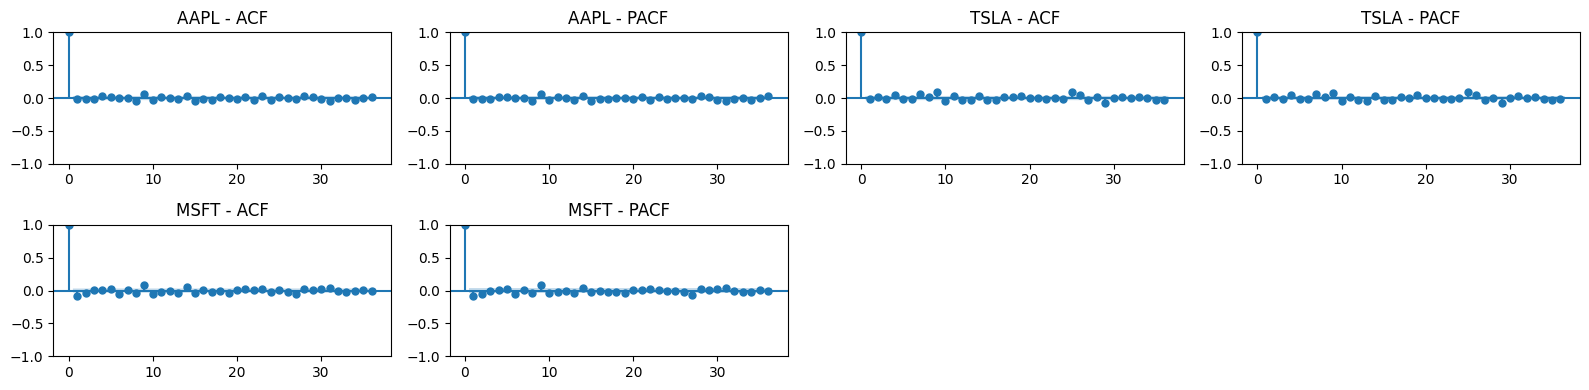

In [7]:
# Autocorrelation (ACF) and Partial Autocorrelation (PACF) plots
def plot_acf_pacf_stocks(stock_data, stocks, per_row=2):
    n_stocks = len(stocks)
    n_rows = (n_stocks + per_row - 1) // per_row
    fig, axes = plt.subplots(n_rows, per_row*2, figsize=(per_row*8, n_rows*2))
    axes = axes.reshape(n_rows, per_row*2)

    for i, stock in enumerate(stocks):
        row = i // per_row
        col = (i % per_row) * 2
        df = stock_data[stock].copy()
        df = df.dropna()
        differenced_prices = df.diff().dropna()

        # ACF
        plot_acf(differenced_prices, ax=axes[row, col])
        axes[row, col].set_title(f'{stock} - ACF')

        # PACF
        plot_pacf(differenced_prices, ax=axes[row, col+1])
        axes[row, col+1].set_title(f'{stock} - PACF')

    for j in range(n_stocks, n_rows*per_row):
        row = j // per_row
        col = (j % per_row) * 2
        axes[row, col].axis('off')
        axes[row, col+1].axis('off')

    plt.tight_layout()
    plt.show()

plot_acf_pacf_stocks(df_adjclose, STOCKS, per_row=2)

Training the model only for 3 stocks.

In [8]:
# check best order using auto arima
model_auto_arima_params = {}
for stock in STOCKS:
    try:
        df = df_adjclose[stock].copy()
        df = df.dropna()
        df = np.log(df_adjclose[stock].dropna())

        model = auto_arima(
            df,
            seasonal=False,
            stepwise=True,
            approximation=False,
            information_criterion='aicc',
            max_p=5, max_q=5,
            suppress_warnings=True,
            error_action="ignore",
            trace=False
        )

        model_auto_arima_params[stock] = {
            "model": model,
            "aic": model.aic(),
            "order": model.order
        }
        print(f"{stock}: Best order = {model.order}, AIC = {model.aic()}")

    except Exception as e:
        print(f"Skipping {stock} due to error: {e}")
        continue

AAPL: Best order = (1, 1, 0), AIC = -20367.45787709945
TSLA: Best order = (0, 1, 0), AIC = -14767.479877949694
MSFT: Best order = (0, 1, 1), AIC = -21021.352794513827


In [9]:
# training the model the the order obtained using auto arima
model_auto_arima = {}
for stock in STOCKS:
    try:
        order = model_auto_arima_params[stock]['order']
        train = train_data[stock].dropna()
        test = test_data[stock].dropna()

        model = ARIMA(train, order=order)
        res = model.fit()

        history = res
        y_pred = []

        for val in test:
            y_pred.append(history.forecast(1).iloc[0])
            history = history.extend([val])

        mae = mean_absolute_error(test, y_pred)
        rmse = np.sqrt(mean_squared_error(test, y_pred))

        model_auto_arima[stock] = {
            "model_object": history,
            "y_test_index": test.index,
            "y_test": test.values,
            "y_pred": y_pred,
            "order": order,
            "metrics": {"mae": round(mae, 4), "rmse": round(rmse, 4), "aic": round(res.aic, 2)}
        }
    except Exception as e:
        print(f"Error processing {stock}: {e}")
        continue

AAPL: ARIMA -> order = (1, 1, 0), AIC = 12305.44, MAE: 2.1153, RMSE: 2.956


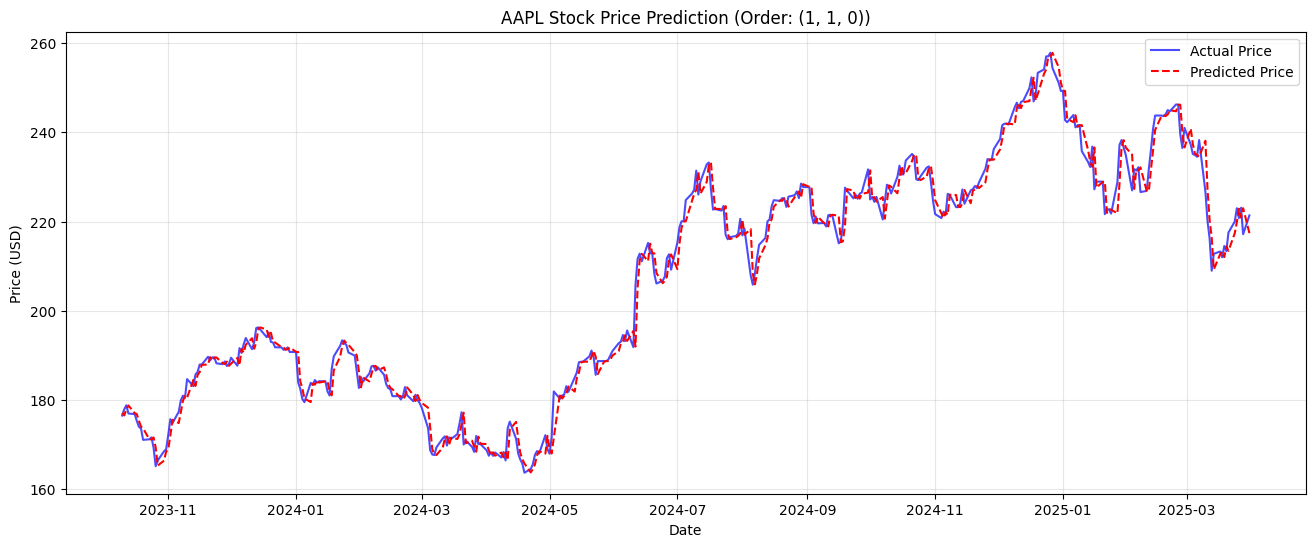

TSLA: ARIMA -> order = (0, 1, 0), AIC = 20312.4, MAE: 6.9281, RMSE: 10.0963


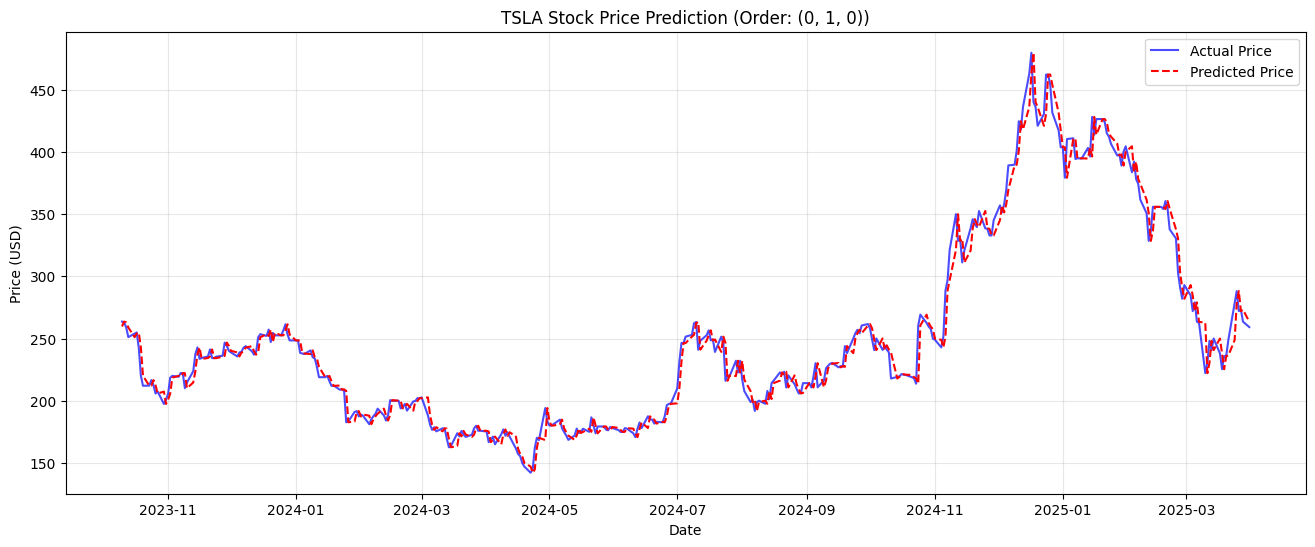

MSFT: ARIMA -> order = (0, 1, 1), AIC = 16331.92, MAE: 3.8207, RMSE: 5.2529


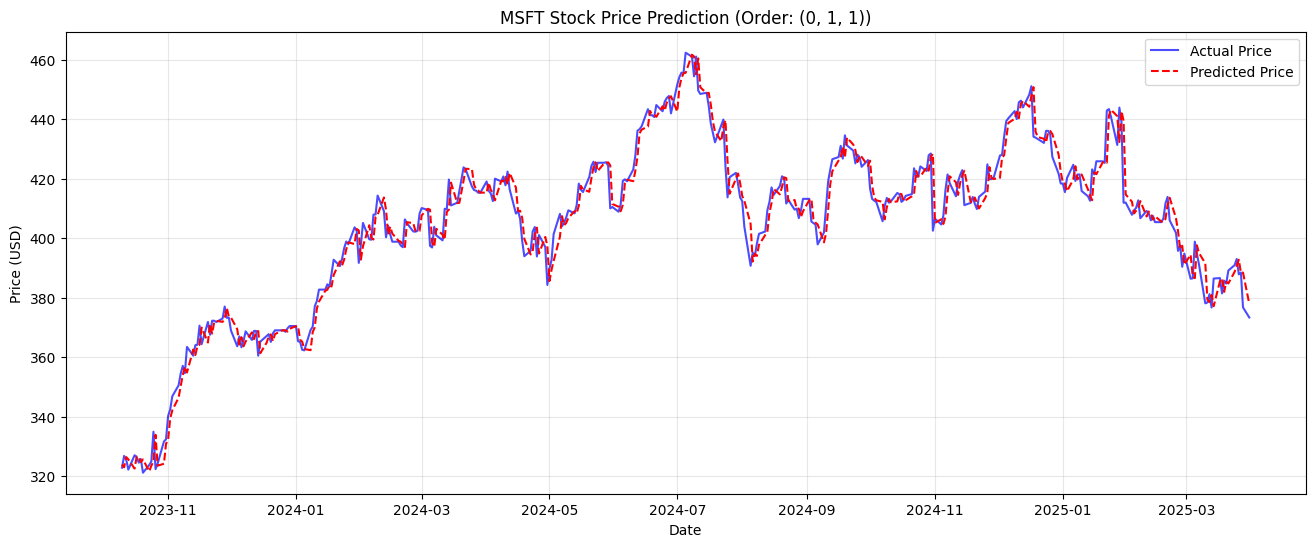

In [10]:
for stock in STOCKS:
    if stock not in model_auto_arima:
        continue

    res = model_auto_arima[stock]
    metrics = res['metrics']
    model_obj = res['model_object']
    current_order = model_obj.specification['order']

    print(f"{stock}: ARIMA -> order = {current_order}, AIC = {metrics['aic']}, MAE: {metrics['mae']}, RMSE: {metrics['rmse']}")
    plt.figure(figsize=(16, 6))

    # Plot Actual vs Predicted using the stored arrays and index
    plt.plot(res['y_test_index'], res['y_test'], label='Actual Price', color='blue', alpha=0.7)
    plt.plot(res['y_test_index'], res['y_pred'], label='Predicted Price', color='red', linestyle='--')

    plt.title(f"{stock} Stock Price Prediction (Order: {current_order})")
    plt.xlabel('Date')
    plt.ylabel('Price (USD)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

AAPL: ARIMA -> order = (5, 1, 0), AIC = 16331.92, MAE: 3.8207, RMSE: 5.2529


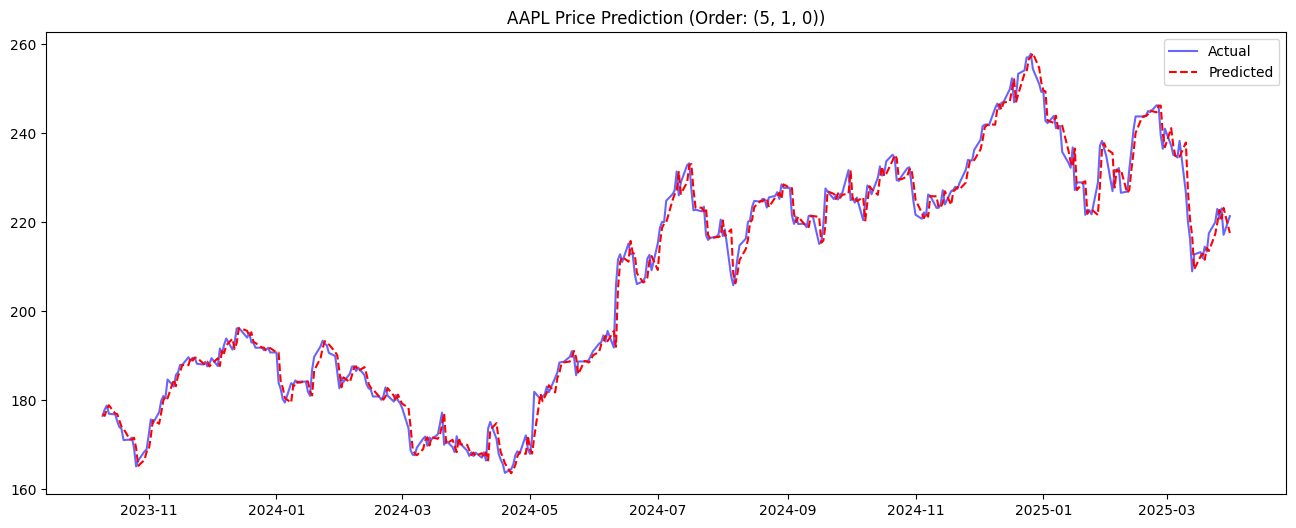

TSLA: ARIMA -> order = (5, 1, 0), AIC = 16331.92, MAE: 3.8207, RMSE: 5.2529


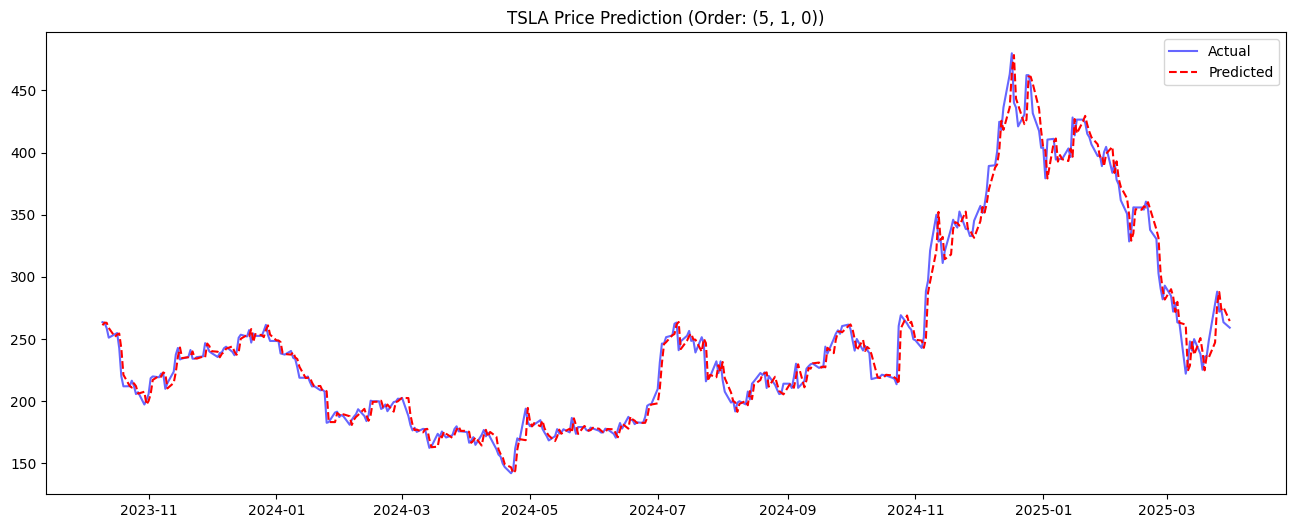

MSFT: ARIMA -> order = (5, 1, 0), AIC = 16331.92, MAE: 3.8207, RMSE: 5.2529


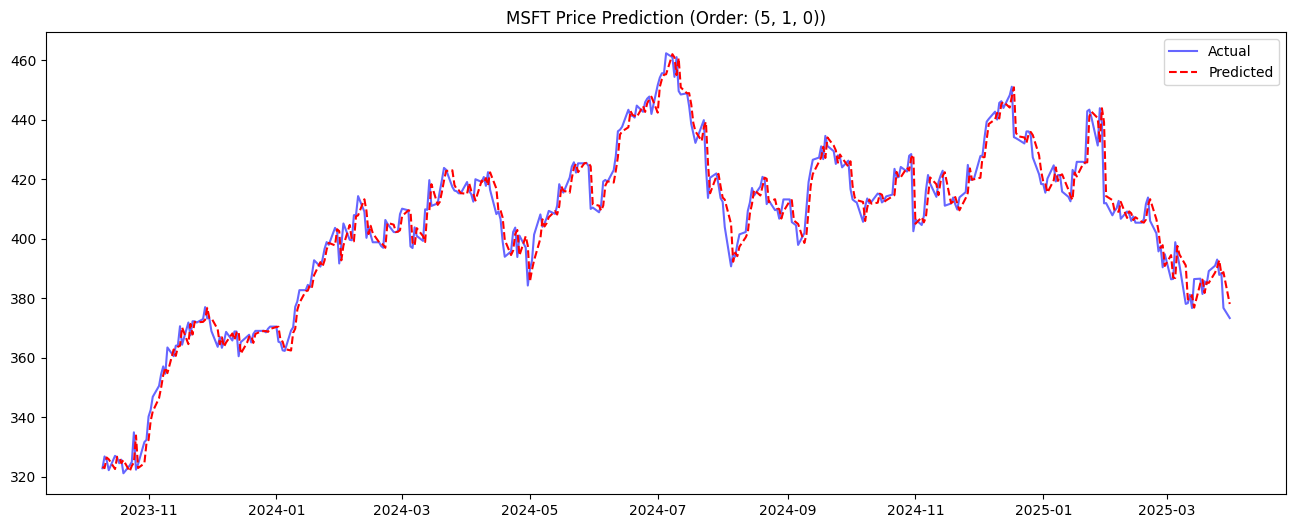

In [11]:
# Train ARIMA model using the order (p=5, d=1, q=0)
model_arima = {}
FIXED_ORDER = (5, 1, 0)

for stock in STOCKS:
    try:
        train = train_data[stock].dropna()
        test = test_data[stock].dropna()

        model = ARIMA(train, order=FIXED_ORDER)
        res = model.fit()
        y_pred = []
        current_res = res

        for val in tqdm(test, desc=f"Forecasting {stock}", leave=False):
            forecast = current_res.forecast(steps=1)
            y_pred.append(forecast.iloc[0])
            current_res = current_res.extend([val])

        mae = mean_absolute_error(test, y_pred)
        rmse = np.sqrt(mean_squared_error(test, y_pred))

        model_arima[stock] = {
            "model_object": current_res,
            "y_test_index": test.index,
            "y_test": test.values,
            "y_pred": y_pred,
            "order": FIXED_ORDER,
            "metrics": {"mae": round(mae, 4), "rmse": round(rmse, 4), "aic": round(res.aic, 2)}
        }
        print(f"{stock}: ARIMA -> order = {FIXED_ORDER}, AIC = {metrics['aic']}, MAE: {metrics['mae']}, RMSE: {metrics['rmse']}")

        plt.figure(figsize=(16, 6))
        plt.plot(test.index, test.values, label='Actual', color='blue', alpha=0.6)
        plt.plot(test.index, y_pred, label='Predicted', color='red', linestyle='--')
        plt.title(f"{stock} Price Prediction (Order: {FIXED_ORDER})")
        plt.legend()
        plt.show()

    except Exception as e:
        print(f"Skipping {stock} due to error: {e}")
        continue

In [12]:
# Save results
joblib.dump(model_arima, OUTPUT_PATH / "models/model_arima.joblib")
joblib.dump(model_auto_arima, OUTPUT_PATH / "models/model_auto_arima.joblib")

['/content/drive/MyDrive/Data Science projects/stock_market_prediction/outputs/models/model_auto_arima.joblib']